<a href="https://colab.research.google.com/github/fcorvetto/cell-pose/blob/main/Notebook_Cellpose" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Segmentación automática de células con Cellpose


Hola! :)

Este es un notebook de Python para correr **Cellpose**, un software de segmentación de células, usando Google Colaboratory.

Cellpose puede tomar como input:
- Imágenes single-channel, en grayscale (IDEAL!)
- Imágenes multi-channel tipo "merge", en RGB (anda pero hay que hacer unos ajustes, si les interesa lo vemos)
  - En este caso, luego hay que especificar qué canal querés usar para la segmentación. (Ver más abajo)
  - Si tenés teñidos los núcleos, este canal puede proveerse como canal 2rio, como información auxiliar que ayuda a la segmentación. (Ver más abajo)
- Formatos .png, .tiff, etc.

Notar que algunas señales citoplasmáticas relativamente homogéneas permiten segmentar directamente, mientras que otras, según el grado de granularidad y el contraste de las imágenes, pueden requerir un preprocesamiento. Si tenés dudas avisame y vemos qué solución podemos armar para tu caso!

Para correr el programa, empezá por subir las imágenes a una carpeta de Drive. Que sea una carpeta que no tenga otras cosas más que esas imágenes.

Luego, hay que linkear el Google Colab con tu Drive. Para eso, ejecutá el siguiente bloque de código:

(Te va a pedir que te loguees en la cuenta de Google y que le des acceso al Drive. Hay que tildarle todo que sí.)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

# Acá abajo le damos acceso a nuestra unidad de Drive
file_root = '/content/drive/My Drive/'

Mounted at /content/drive


A continuación **hay que instalar cellpose**. Esto debe hacerse cada vez que se corre el script, dado que no estamos dejando instalado el programa en nuestro Drive. No tarda mucho en correr (notar que tiene que descargar paquetes de internet, así que una buena conexión ayuda).

En esta celda también se instalan versiones específicas de numpy y opencv, para asegurarnos que cellpose corra.

In [ ]:
# Desinstalar si hay versiones distintas de numpy, opencv y cellpose por si hay problemas de compatibilidad

!pip uninstall -y numpy opencv-python opencv-python-headless cellpose

# Instalar versiones que seguro funcionan
!pip install numpy==1.26.4
!pip install opencv-python==4.10.0.84
!pip install cellpose==3.1.0

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: opencv-python 4.13.0.92
Uninstalling opencv-python-4.13.0.92:
  Successfully uninstalled opencv-python-4.13.0.92
Found existing installation: opencv-python-headless 4.13.0.92
Uninstalling opencv-python-headless-4.13.0.92:
  Successfully uninstalled opencv-python-headless-4.13.0.92
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 67.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dopamine-rl 4.1.2 requires opencv-python>=3.4.8.29, which is not installed.
albucore 0.0.24 requires opencv-python-headless>=4.9.0.80, which is not installed.
albumentations 2.0.8 requires opencv-python-headless>=4.9.0.80, which is not installed.
ra

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.2/215.2 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.8/6.8 MB 82.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 26.5/26.5 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.2/19.2 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 10.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4


**IMPORTANTE: Cuando termina de correr la celda anterior, hay que reiniciar el entorno para que se guarden los cambios en los paquetes instalados.**

Para eso ir a la barra superior: Runtime > Restart Session (o usar el comando "Ctrl + M + .").

**Una vez hecho esto, seguir ejecutando el resto del notebook..**

Con la siguiente celda cargamos una serie de paquetes que vamos a necesitar:

In [ ]:
import numpy as np
import scipy as sp
import skimage as ski
import os
import cellpose as cp
from matplotlib import pyplot as plt
from skimage import data, color
from skimage.transform import rescale, resize, downscale_local_mean
from cellpose import models, io
from cellpose.io import imread

Ya podemos empezar! :)

## 1. Carga de imágenes

En la próxima celda, escribí la ruta de la carpeta donde pusiste las fotos a segmentar, con el siguiente formato:


```
pathNoStar = "/content/drive/MyDrive/Ruta/A/Carpeta/Con/Fotos/"
```


In [ ]:
#### Carga de imágenes ####
## Modificar las próximas dos líneas:
path = "/content/drive/MyDrive/Cellpose/imagnes/*"
pathNoStar = "/content/drive/MyDrive/Cellpose/imagnes/" # Esto para el guardado de los outputs


# Get the list of files and filter out non-image files (like .zip)
import glob
all_files = glob.glob(path)
image_files = [f for f in all_files if not f.endswith('.zip')]

imgs = ski.io.imread_collection(image_files)
file_list = imgs.files    # Guardo la lista de paths de archivos para nombrar los outputs más adelante





Chequeamos que nos haya tomado bien la lista pidiendo que nos la imprima:

In [ ]:
file_list

['/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_0.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_1.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_2.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_3.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_4.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_5.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_6.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_7.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_8.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C1_.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C2_0.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C2_1.tif',
 '/content/drive/MyDrive/Cellpose/imagnes/mSmaug1SpmdhSmaug1EYFP_C2_2.tif',
 '/content/dr

## 2. *Downscaling*

El próximo paso es hacer un *downscaling* de las imágenes. Esto baja la cantidad de píxeles, para que el Cellpose corra más rápido (y muchas veces, mejor).

El factor de downscaling hay que especificarlo en esta celda y ya queda definido globalmente. Esto permite volver a usar el mismo número más adelante para el *upscaling* de las segmentaciones hechas sobre imágenes downscaleadas.

In [ ]:
#### Downscaling ####
factor = 5    # Defino el factor globalmente para volver a usarlo en el upscaling de las máscaras
imgs_ds = []  # imgs_ds será la lista de imágenes downscaleadas
for i in range(len(imgs)):
    imgs_ds.append(downscale_local_mean(imgs[i], factor))




Para ver que se hayan downscaleado OK, correr el siguiente bloque de código que permite visualizar las imágenes. También es útil para tener una idea del tamaño de las células (en px) en las imágenes downscaleadas, importante para el paso de segmentación!

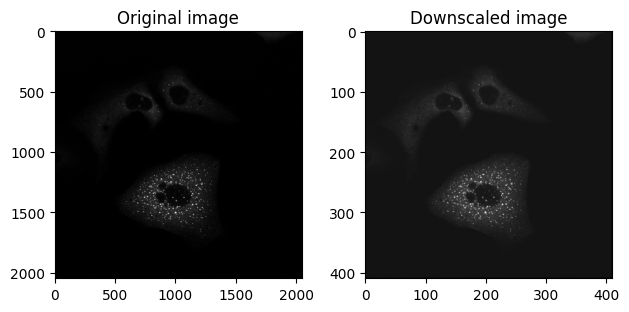

In [ ]:
fig, axes = plt.subplots(nrows=1, ncols=2)

ax = axes.ravel()

ax[0].imshow(imgs[2], cmap='gray')
ax[0].set_title("Original image")

ax[1].imshow(imgs_ds[2], cmap='gray')
ax[1].set_title("Downscaled image")

plt.tight_layout()
plt.show()

## 3. Segmentación con Cellpose

Acá es donde corremos el software de segmentación.

Si estás procesando muchas imágenes, conviene primero hacer la prueba con una sola imagen, a ver cómo está funcionando, y si hace falta modificar algún parámetro. La celda siguiente segmenta sólo la primera imagen de la carpeta, y te muestra los resultados.

Hay varias cosas que se pueden modificar:
- El modelo utilizado, de una serie de modelos pre-entrenados.
  - "cyto", "cyto2", "cyto3" para segmentar con señal citoplasmática
  - "nuclei" si estás segmentando núcleos
- Los canales a usar en la segmentación.
  - Definimos los canales a segmentar utilizando números: grayscale = 0; R = 1; G = 2; B = 3
  - La convención es: channels = [citoplasma, núcleo] (Si no hay canal de núcleo, éste se setea a 0.)
  - Por ejemplo:
    - channels = [0, 0] si tenés sólo señal citoplasmática en grayscale
    - channels = [2, 3] si tenés una imagen RGB con el citoplasma en verde (G = 2) y núcleo en azul (B = 3)
- El diámetro promedio (en px) de las células (o núcleos) que estás segmentando.
  - Notar que este diámetro es en las fotos downscaleadas, sobre las cuales vamos a correr la segmentación. Guiarse por la escala en la visualización de más arriba.
  - Si se setea diameter = None, el programa estima el tamaño de las células en cada foto (no recomendado!).
- *Thresholds* del modelo. (Bien explicados en https://cellpose.readthedocs.io/en/latest/settings.html#settings)
  - flow_threshold: aumentalo si aparecen menos ROIs de las que esperarías; disminuilo si aparecen muchas ROIs mal definidas/con formas raras/que no son células. Valor por default: 0.4.
  - cellprob_threshold: disminuilo si aparecen menos ROIs de las que esperarías; aumentalo si aparecen demasiadas ROIs, en particular en áreas "oscuras"/con poca señal. Valor por default: 0.0.

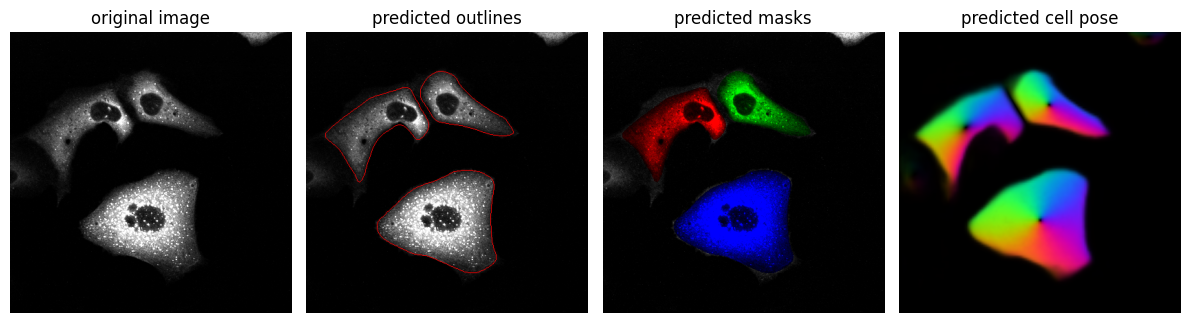

In [ ]:
#### Segmentación de una sola imagen ####
io.logger_setup()

## Con la próxima línea de código se elige el modelo de segmentación que se quiere correr.
# Para una señal citoplasmática, model_type = "cyto2" anda genial
model = models.Cellpose(model_type='cyto2')

## Lista de imágenes que vamos a segmentar (en este caso sólo es la primera)
images = imgs_ds[2] ## Podés probar con otras imágenes de la lista cambiando el índice "0" por otro número
nimg = len(images)

## Definimos los canales a segmentar utilizando números:
channels = [[0, 0]]

## Parámetros del modelo: acá se pueden modificar los parámetros que necesites
diametro = 100 ## En pixeles; mirar escala de la imagen post-downscaling
flow_thr = 0.4 ## Default: 0.4, en principio no hace falta cambiarlo
cellprob_thr = 0.0 ## Default: 0.0, en principio no hace falta cambiarlo

## Ahora se corre el modelo:
masks, flows, styles, diams = model.eval(images,
                                         diameter = diametro,
                                         channels = channels,
                                         flow_threshold = flow_thr,
                                         cellprob_threshold = cellprob_thr)

## Y vemos qué dio
from cellpose import plot
fig = plt.figure(figsize=(12,5))
plot.show_segmentation(fig, images, masks, flows[0])
plt.tight_layout()
plt.show()




Si te gustaría mejorar algo, probá modificando los parámetros en el modelo. **Recordá:** no conviene obsesionarse con que una imagen sea segmentada a la perfección, sino que la segmentación debe funcionar **suficientemente bien** para **todas** nuestras imágenes.

Si ya estás conforme, ahora corré la segmentación en batch ejecutando la celda que sigue. Los parámetros son los que ya definiste en la celda anterior, por lo que no hace falta modificar nada en la celda siguiente.

In [ ]:
#### Segmentación en batch ####
io.logger_setup()

## Lista de imágenes que vamos a segmentar
images = imgs_ds
nimg = len(images)

## Ahora se corre el modelo:
masks, flows, styles, diams = model.eval(images,
                                         diameter = diametro,
                                         channels = channels,
                                         flow_threshold = flow_thr,
                                         cellprob_threshold = cellprob_thr)


## 4. *Upscaling* de las máscaras y guardado de las ROIs

Ya casi terminamos!

El modelo generó segmentaciones de las imágenes downscaleadas. Si usamos estas ROIs directo sobre nuestras imágenes originales, van a andar mal, porque las ROIs fueron dibujadas sobre imágenes con una menor cantidad de píxeles!

Lo que queda es "upscalear" las ROIs obtenidas para que tengan tamaños compatibles con las imágenes originales, donde después queremos hacer nuestros análisis. Estas ROIs upscaleadas se guardan como ROIsets para ImageJ, en formato .zip, en la misma carpeta donde pusimos las imágenes.

In [ ]:
#### Upscaling de las máscaras y guardado a .zip ####
masks_ups = []
for i in range(len(masks)):
    masks_ups.append(np.repeat(np.repeat(masks[i], repeats = factor, axis = 0), repeats = factor, axis = 1))

from pathlib import Path
for i in range(len(masks_ups)):
    fileName = Path(file_list[i]).stem
    io.save_rois(masks_ups[i], pathNoStar + fileName)

Listo!

Las ROIs generadas para cada foto están guardadas en la misma carpeta donde pusiste las imágenes, ya podés descargarlas y usarlas para análisis posteriores en ImageJ.

El output de segmentación puede ser otro; por ejemplo, podés exportar máscaras en vez de ROIs, como mapas de labels donde los px de cada célula tienen un label distinto. Si querés saber más al respecto, lo vemos, o podés revisar la documentación de Cellpose (https://cellpose.readthedocs.io/en/latest/).

Feliz segmentación!!!

:)